In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sahajs6200/hinglish/Combined.csv


In [2]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [3]:
df = pd.read_csv("/kaggle/input/datasets/sahajs6200/hinglish/Combined.csv")
print(df["label"].value_counts())

label
neutral     12120
positive    11533
negative    10916
Name: count, dtype: int64


In [5]:
import pandas as pd
import torch
import torch.nn as nn
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

from transformers import (
    AutoTokenizer,
    AutoModel,
    TrainingArguments,
    Trainer
)

# =========================
# 1. Load Dataset
# =========================
df = pd.read_csv("/kaggle/input/datasets/sahajs6200/hinglish/Combined.csv")
df = df.dropna(subset=["processed_text"])

# =========================
# 2. Label Encoding
# =========================
label_map = {"negative": 0, "neutral": 1, "positive": 2}
df["label"] = df["label"].map(label_map)

# =========================
# 3. NOVELTY #1: Token Augmentation (existing)
# =========================
def transform_text(text):
    words = text.split()
    new_words = []
    for w in words:
        parts = w.split("_")
        if len(parts) == 2:
            new_words.append(parts[0])
            new_words.append("<" + parts[1] + ">")
        else:
            new_words.append(w)
    return " ".join(new_words)

df["processed_text"] = df["processed_text"].apply(transform_text)

# =========================
# 4. Train-Test Split
# =========================
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["processed_text"],
    df["label"],
    test_size=0.2,
    random_state=42
)

# =========================
# 5. Tokenizer + Special Tokens
# =========================
tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

special_tokens = ["<EN>", "<HI>", "<POS>", "<NEG>"]
tokenizer.add_tokens(special_tokens)

# Map special token string → token ID (used later for gate + warm init)
special_token_ids = {tok: tokenizer.convert_tokens_to_ids(tok) for tok in special_tokens}
print("Special token IDs:", special_token_ids)

# =========================
# 6. Tokenization
# =========================
train_encodings = tokenizer(list(train_texts), truncation=True, padding=True, max_length=64)
test_encodings  = tokenizer(list(test_texts),  truncation=True, padding=True, max_length=64)

# =========================
# 7. Dataset Class
# =========================
class HinglishDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.reset_index(drop=True)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = HinglishDataset(train_encodings, train_labels)
test_dataset  = HinglishDataset(test_encodings,  test_labels)

# =====================================================================
# 8. NOVELTY #2: Warm-Initialized Sentiment Token Embeddings
#    Seed words for each special token — averaged into its embedding
# =====================================================================
SEED_WORDS = {
    "<POS>": ["good", "great", "excellent", "happy", "love", "wonderful", "amazing", "fantastic"],
    "<NEG>": ["bad",  "terrible", "awful", "hate", "horrible", "disgusting", "worst", "sad"],
    "<EN>":  ["the", "is", "and", "this", "that", "with", "from", "about"],
    "<HI>":  ["yaar", "bhai", "acha", "theek", "nahi", "hai", "kya", "mera"],
}

def warm_init_special_tokens(model, tokenizer, seed_words_map):
    """
    Replace the random embeddings of special tokens with the mean
    of their corresponding seed-word embeddings.
    """
    embedding_layer = model.embeddings.word_embeddings
    with torch.no_grad():
        for special_tok, seeds in seed_words_map.items():
            seed_ids = tokenizer.convert_tokens_to_ids(
                tokenizer.tokenize(" ".join(seeds))
            )
            # Filter out unknowns
            seed_ids = [sid for sid in seed_ids if sid != tokenizer.unk_token_id]
            if not seed_ids:
                continue
            seed_embeddings = embedding_layer.weight[seed_ids]   # (N, hidden)
            mean_embedding  = seed_embeddings.mean(dim=0)        # (hidden,)

            special_id = tokenizer.convert_tokens_to_ids(special_tok)
            embedding_layer.weight[special_id] = mean_embedding

    print("✅ Warm initialization of special token embeddings complete.")

# =====================================================================
# 9. NOVELTY #3: Language-Aware Attention Gating Model
#
#    Architecture:
#      XLM-RoBERTa encoder
#           ↓  (all token hidden states)
#      Lang-Gate MLP  ← detects <EN>/<HI> tag positions → scalar gate per token
#           ↓  (gated weighted pooling)
#      Gated Sentence Representation
#           ↓
#      Linear Classifier (3 classes)
# =====================================================================
class LanguageGatedSentimentModel(nn.Module):
    def __init__(self, encoder, hidden_size, num_labels,
                 en_token_id, hi_token_id):
        super().__init__()
        self.encoder      = encoder
        self.num_labels   = num_labels
        self.en_token_id  = en_token_id
        self.hi_token_id  = hi_token_id

        # Gate MLP: takes [token_hidden ; lang_flag] → scalar gate score
        # lang_flag is a 2-dim one-hot: [is_EN, is_HI]
        self.gate_mlp = nn.Sequential(
            nn.Linear(hidden_size + 2, 128),
            nn.ReLU(),
            nn.Linear(128, 1),           # one scalar per token
            nn.Sigmoid()                 # gate ∈ (0, 1)
        )

        # Final classifier on gated pooled representation
        self.dropout    = nn.Dropout(0.1)
        self.classifier = nn.Linear(hidden_size, num_labels)

    def forward(self, input_ids, attention_mask, token_type_ids=None, labels=None):
        # ── Encoder ──────────────────────────────────────────────────
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        hidden_states = outputs.last_hidden_state   # (B, T, H)

        # ── Build language flag for each token position ───────────────
        # Shape: (B, T, 2) — [is_EN_tag, is_HI_tag]
        is_en = (input_ids == self.en_token_id).float().unsqueeze(-1)   # (B,T,1)
        is_hi = (input_ids == self.hi_token_id).float().unsqueeze(-1)   # (B,T,1)
        lang_flags = torch.cat([is_en, is_hi], dim=-1)                  # (B,T,2)

        # ── Gate MLP ─────────────────────────────────────────────────
        gate_input  = torch.cat([hidden_states, lang_flags], dim=-1)    # (B,T,H+2)
        gate_scores = self.gate_mlp(gate_input).squeeze(-1)             # (B,T)

        # Mask out padding tokens
        gate_scores = gate_scores * attention_mask.float()              # (B,T)

        # ── Gated Weighted Pooling ────────────────────────────────────
        # Normalise gate scores over non-padding positions
        gate_weights = gate_scores / (gate_scores.sum(dim=1, keepdim=True) + 1e-9)
        gated_repr   = (hidden_states * gate_weights.unsqueeze(-1)).sum(dim=1)  # (B,H)

        # ── Classification ────────────────────────────────────────────
        logits = self.classifier(self.dropout(gated_repr))              # (B, num_labels)

        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)

        # Return a simple namespace so HuggingFace Trainer is happy
        from transformers.modeling_outputs import SequenceClassifierOutput
        return SequenceClassifierOutput(
            loss=loss,
            logits=logits,
            hidden_states=None,
            attentions=None
        )

# =========================
# 10. Instantiate Model
# =========================
base_encoder = AutoModel.from_pretrained("xlm-roberta-base")
base_encoder.resize_token_embeddings(len(tokenizer))

model = LanguageGatedSentimentModel(
    encoder      = base_encoder,
    hidden_size  = 768,
    num_labels   = 3,
    en_token_id  = special_token_ids["<EN>"],
    hi_token_id  = special_token_ids["<HI>"]
)

# Apply warm initialization AFTER model is built
warm_init_special_tokens(base_encoder, tokenizer, SEED_WORDS)

# =========================
# 11. Metrics
# =========================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='weighted', zero_division=0
    )
    acc = accuracy_score(labels, predictions)
    return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}

# =========================
# 12. Training Arguments
# =========================
training_args = TrainingArguments(
    output_dir                  = "./results",
    num_train_epochs            = 4,
    per_device_train_batch_size = 8,
    per_device_eval_batch_size  = 8,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    learning_rate               = 2e-5,
    logging_steps               = 100,
    load_best_model_at_end      = True
)

# =========================
# 13. Trainer
# =========================
trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_dataset,
    eval_dataset    = test_dataset,
    compute_metrics = compute_metrics
)

# =========================
# 14. Train
# =========================
trainer.train()

# =========================
# 15. Evaluate
# =========================
results = trainer.evaluate()
print(results)

# =========================
# 16. Confusion Matrix
# =========================
predictions = trainer.predict(test_dataset)
y_pred = predictions.predictions.argmax(axis=1)
cm = confusion_matrix(test_labels, y_pred)
print("Confusion Matrix:\n", cm)

# =========================
# 17. Error Analysis
# =========================
for i in range(len(test_texts)):
    if y_pred[i] != test_labels.iloc[i]:
        print("Text:",      test_texts.iloc[i])
        print("Actual:",    test_labels.iloc[i])
        print("Predicted:", y_pred[i])
        print("------")

Special token IDs: {'<EN>': 250002, '<HI>': 250003, '<POS>': 250004, '<NEG>': 250005}


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Warm initialization of special token embeddings complete.


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.381648,0.378383,0.813250,0.810812,0.830245,0.813250
2,0.354333,0.365275,0.830754,0.829452,0.830653,0.830754
3,0.334725,0.369120,0.832779,0.831814,0.833017,0.832779
4,0.283047,0.395681,0.830898,0.829892,0.830991,0.830898


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector

{'eval_loss': 0.36527490615844727, 'eval_accuracy': 0.8307536525386953, 'eval_f1': 0.8294521092810363, 'eval_precision': 0.8306526581930403, 'eval_recall': 0.8307536525386953, 'eval_runtime': 56.2253, 'eval_samples_per_second': 122.952, 'eval_steps_per_second': 7.701, 'epoch': 4.0}


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Confusion Matrix:
 [[1856  214   73]
 [ 288 1816  338]
 [  97  160 2071]]
Text: din <EN> dekhog <HI> v <HI> murkh <HI> mann <EN> pichh <HI> mat <EN> hatna <HI> nan <EN>
Actual: 0
Predicted: 1
------
Text: nahi <HI> apki <HI> love <EN>
Actual: 2
Predicted: 1
------
Text: ur <HI> dhun <HI> pakistan <EN> lya <HI> pakistan <EN> bahir <HI> nahi <HI> lay <EN> kr <HI> papri <HI> walay <HI> c <HI> nan <EN>
Actual: 1
Predicted: 0
------
Text: eid <EN> arh <HI> r <HI> ik <HI> milna <HI> r <HI> eid <EN> yyari <HI> krni <HI>
Actual: 2
Predicted: 1
------
Text: tinka <HI> shit <EN> nan <EN>
Actual: 1
Predicted: 2
------
Text: nana <EN> ji <HI> rehn <HI> dijiy <HI> desh <HI> jnta <HI> kisp <HI> kichd <HI> uchal <HI> h <HI> kahn <EN> kahn <EN> kamal <EN> khi <HI>
Actual: 0
Predicted: 1
------
Text: kijiy <HI> din <EN> shuruat <HI> bajrang <HI> bali <EN> bajrangi <HI> feel <EN> bles <HI> voic <HI> nan <EN>
Actual: 1
Predicted: 2
------
Text: jnta <HI> nahi <HI> muslmano <HI> condom <EN> dena <HI>
Actu

In [6]:
import os
os.makedirs("/kaggle/working/hinglish_model", exist_ok=True)

# Save the encoder (XLM-RoBERTa backbone)
base_encoder.save_pretrained("/kaggle/working/hinglish_model/encoder")

# Save the tokenizer (with your special tokens)
tokenizer.save_pretrained("/kaggle/working/hinglish_model/tokenizer")

# Save the full model weights (gate MLP + classifier head)
torch.save(model.state_dict(), "/kaggle/working/hinglish_model/model_weights.pt")

print("✅ Model saved!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model saved!


In [7]:
import json

config = {
    "hidden_size": 768,
    "num_labels": 3,
    "en_token_id": special_token_ids["<EN>"],
    "hi_token_id": special_token_ids["<HI>"],
    "label_map": {"0": "negative", "1": "neutral", "2": "positive"}
}

with open("/kaggle/working/hinglish_model/config.json", "w") as f:
    json.dump(config, f)

print("✅ Config saved!")

✅ Config saved!


In [8]:
!zip -r output_files.zip /kaggle/working/hinglish_model

  adding: kaggle/working/hinglish_model/ (stored 0%)
  adding: kaggle/working/hinglish_model/model_weights.pt (deflated 30%)
  adding: kaggle/working/hinglish_model/config.json (deflated 28%)
  adding: kaggle/working/hinglish_model/tokenizer/ (stored 0%)
  adding: kaggle/working/hinglish_model/tokenizer/tokenizer.json (deflated 77%)
  adding: kaggle/working/hinglish_model/tokenizer/tokenizer_config.json (deflated 47%)
  adding: kaggle/working/hinglish_model/encoder/ (stored 0%)
  adding: kaggle/working/hinglish_model/encoder/config.json (deflated 51%)
  adding: kaggle/working/hinglish_model/encoder/model.safetensors (deflated 30%)


In [9]:
!ls

hinglish_model	output_files.zip  results


In [10]:
from IPython.display import FileLink
FileLink(r'output_files.zip')

/kaggle/working/output_files.zip

In [4]:
import pandas as pd
import torch
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

# =========================
# 1. Load & Prepare Data
# =========================
df = pd.read_csv("/kaggle/input/datasets/sahajs6200/hinglish/Combined.csv")
df = df.dropna(subset=["processed_text"])

label_map = {"negative": 0, "neutral": 1, "positive": 2}
df["label"] = df["label"].map(label_map)

# Same preprocessing as your main model
def transform_text(text):
    words = text.split()
    new_words = []
    for w in words:
        parts = w.split("_")
        if len(parts) == 2:
            new_words.append(parts[0])
            new_words.append("<" + parts[1] + ">")
        else:
            new_words.append(w)
    return " ".join(new_words)

df["processed_text"] = df["processed_text"].apply(transform_text)

train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["processed_text"],
    df["label"],
    test_size=0.2,
    random_state=42        # same split as your main model
)

# =========================
# 2. Dataset Class
# =========================
class HinglishDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.reset_index(drop=True)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# =========================
# 3. Metrics
# =========================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='weighted', zero_division=0
    )
    acc = accuracy_score(labels, predictions)
    return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}

# =========================
# 4. Models to Compare
# =========================
MODELS_TO_COMPARE = {
    "mBERT":         "bert-base-multilingual-cased",
    "XLM-R Vanilla": "xlm-roberta-base",
    "MuRIL":         "google/muril-base-cased",
}

baseline_results = {}

for model_name, model_path in MODELS_TO_COMPARE.items():
    print(f"\n{'='*55}")
    print(f"  Training: {model_name}")
    print(f"{'='*55}")

    # Tokenizer
    tok = AutoTokenizer.from_pretrained(model_path)
    tr_enc = tok(list(train_texts), truncation=True, padding=True, max_length=64)
    te_enc = tok(list(test_texts),  truncation=True, padding=True, max_length=64)

    tr_ds = HinglishDataset(tr_enc, train_labels)
    te_ds = HinglishDataset(te_enc, test_labels)

    # Model
    mdl = AutoModelForSequenceClassification.from_pretrained(model_path, num_labels=3)

    # Training args
    args = TrainingArguments(
        output_dir                  = f"./results_{model_name.replace(' ', '_')}",
        num_train_epochs            = 1,
        per_device_train_batch_size = 8,
        per_device_eval_batch_size  = 8,
        eval_strategy               = "epoch",
        save_strategy               = "no",
        learning_rate               = 2e-5,
        logging_steps               = 100,
        load_best_model_at_end      = False
    )

    trainer = Trainer(
        model           = mdl,
        args            = args,
        train_dataset   = tr_ds,
        eval_dataset    = te_ds,
        compute_metrics = compute_metrics
    )

    trainer.train()

    result = trainer.evaluate()
    preds  = trainer.predict(te_ds)
    y_pred = preds.predictions.argmax(axis=1)
    cm     = confusion_matrix(test_labels, y_pred)

    baseline_results[model_name] = {
        "accuracy":  result["eval_accuracy"],
        "f1":        result["eval_f1"],
        "precision": result["eval_precision"],
        "recall":    result["eval_recall"],
        "cm":        cm
    }

    print(f"\n✅ {model_name} → Accuracy: {result['eval_accuracy']:.4f} | F1: {result['eval_f1']:.4f}")
    print(f"Confusion Matrix:\n{cm}")

# =========================
# 5. Final Comparison Table
# =========================
# Add your model's results manually
baseline_results["Your Model (XLM-R + Gate + Warm Init)"] = {
    "accuracy":  0.8308,
    "f1":        0.8295,
    "precision": 0.8307,
    "recall":    0.8308,
}

print("\n")
print("="*75)
print(f"{'Model':<40} {'Accuracy':>10} {'F1':>10} {'Precision':>10} {'Recall':>10}")
print("="*75)
for name, res in baseline_results.items():
    print(
        f"{name:<40} "
        f"{res['accuracy']:>10.4f} "
        f"{res['f1']:>10.4f} "
        f"{res['precision']:>10.4f} "
        f"{res['recall']:>10.4f}"
    )
print("="*75)

# Save to CSV
import pandas as pd
rows = [{"Model": n, "Accuracy": round(r["accuracy"]*100, 2),
         "F1": round(r["f1"]*100, 2), "Precision": round(r["precision"]*100, 2),
         "Recall": round(r["recall"]*100, 2)}
        for n, r in baseline_results.items()]
pd.DataFrame(rows).to_csv("/kaggle/working/comparison_results.csv", index=False)
print("\n📊 Saved to comparison_results.csv")


  Training: mBERT


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

BertForSequenceClassification LOAD REPORT from: google/muril-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expe

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.909769,0.896882,0.826848,0.826126,0.826331,0.826848


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]



✅ MuRIL → Accuracy: 0.8268 | F1: 0.8261
Confusion Matrix:
[[1871  215   57]
 [ 312 1845  285]
 [  87  241 2000]]


Model                                      Accuracy         F1  Precision     Recall
mBERT                                        0.8289     0.8286     0.8287     0.8289
XLM-R Vanilla                                0.5125     0.4617     0.4823     0.5125
MuRIL                                        0.8268     0.8261     0.8263     0.8268
Your Model (XLM-R + Gate + Warm Init)        0.8308     0.8295     0.8307     0.8308

📊 Saved to comparison_results.csv


In [1]:
print("Yes")

Yes


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Reverse label map to get names back
reverse_label_map = {0: "Negative", 1: "Neutral", 2: "Positive"}

# Count distributions
train_counts = train_labels.map(reverse_label_map).value_counts().sort_index()
test_counts  = test_labels.map(reverse_label_map).value_counts().sort_index()

# Build table
split_df = pd.DataFrame({
    "Class":            ["Negative", "Neutral", "Positive"],
    "Train Samples":    [train_counts.get("Negative", 0), train_counts.get("Neutral", 0), train_counts.get("Positive", 0)],
    "Test Samples":     [test_counts.get("Negative", 0),  test_counts.get("Neutral", 0),  test_counts.get("Positive", 0)],
})

split_df["Train %"] = (split_df["Train Samples"] / split_df["Train Samples"].sum() * 100).round(2)
split_df["Test %"]  = (split_df["Test Samples"]  / split_df["Test Samples"].sum()  * 100).round(2)
split_df["Total"]   = split_df["Train Samples"] + split_df["Test Samples"]

# Totals row
totals = pd.DataFrame([{
    "Class":         "Total",
    "Train Samples": split_df["Train Samples"].sum(),
    "Test Samples":  split_df["Test Samples"].sum(),
    "Train %":       100.0,
    "Test %":        100.0,
    "Total":         split_df["Total"].sum()
}])

split_df = pd.concat([split_df, totals], ignore_index=True)

print(split_df.to_string(index=False))

   Class  Train Samples  Test Samples  Train %  Test %  Total
Negative           8772          2143    31.73   31.00  10915
 Neutral           9673          2442    34.98   35.32  12115
Positive           9205          2328    33.29   33.68  11533
   Total          27650          6913   100.00  100.00  34563


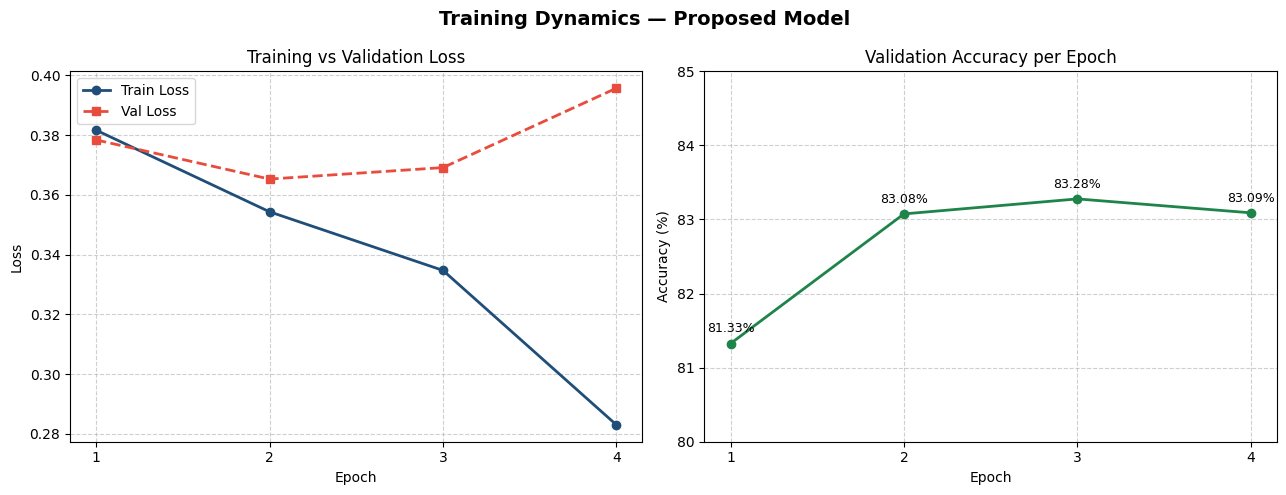

In [2]:
import matplotlib.pyplot as plt

epochs = [1, 2, 3, 4]
train_loss = [0.381648, 0.354333, 0.334725, 0.283047]
val_loss   = [0.378383, 0.365275, 0.369120, 0.395681]
accuracy   = [81.3250, 83.0754, 83.2779, 83.0898]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Training Dynamics — Proposed Model", fontsize=14, fontweight="bold")

# Loss curve
ax1.plot(epochs, train_loss, marker="o", color="#1F4E79", linewidth=2, label="Train Loss")
ax1.plot(epochs, val_loss,   marker="s", color="#E74C3C", linewidth=2, linestyle="--", label="Val Loss")
ax1.set_title("Training vs Validation Loss", fontsize=12)
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.set_xticks(epochs)
ax1.legend(); ax1.grid(True, linestyle="--", alpha=0.6)

# Accuracy curve
ax2.plot(epochs, accuracy, marker="o", color="#1E8449", linewidth=2)
ax2.set_title("Validation Accuracy per Epoch", fontsize=12)
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)")
ax2.set_ylim(80, 85); ax2.set_xticks(epochs)
ax2.grid(True, linestyle="--", alpha=0.6)

for i, acc in enumerate(accuracy):
    ax2.annotate(f"{acc:.2f}%", (epochs[i], acc),
                 textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("/kaggle/working/training_curves.png", dpi=150)
plt.show()

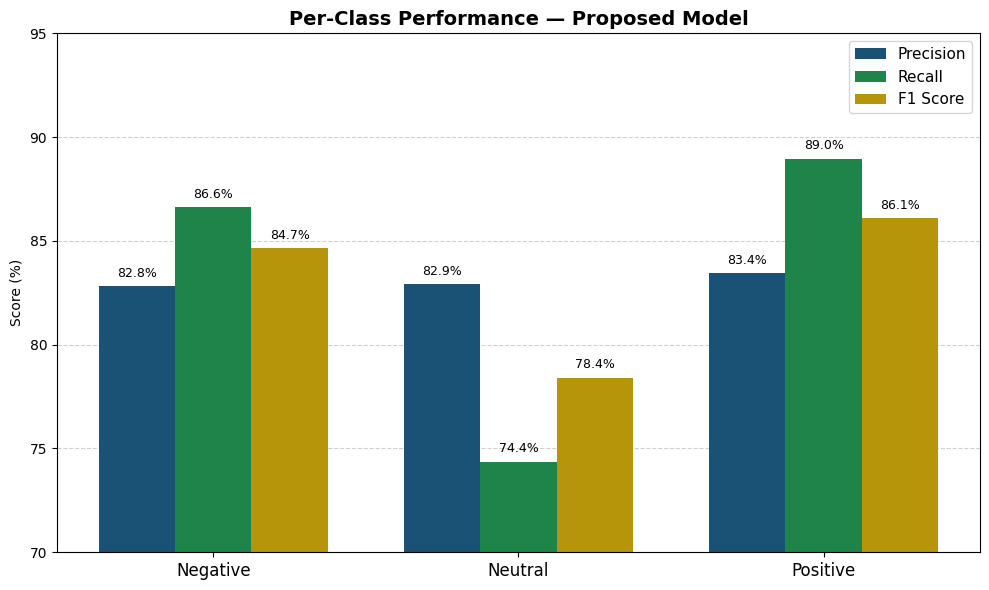

In [3]:
import numpy as np

# From your confusion matrix
# [[1856, 214, 73], [288, 1816, 338], [97, 160, 2071]]
classes   = ["Negative", "Neutral", "Positive"]
precision = [1856/(1856+288+97),  1816/(214+1816+160), 2071/(73+338+2071)]
recall    = [1856/(1856+214+73),  1816/(288+1816+338), 2071/(97+160+2071)]
f1_scores = [2*p*r/(p+r) for p, r in zip(precision, recall)]

precision = [round(p*100, 2) for p in precision]
recall    = [round(r*100, 2) for r in recall]
f1_scores = [round(f*100, 2) for f in f1_scores]

x     = np.arange(len(classes))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
b1 = ax.bar(x - width, precision, width, label="Precision", color="#1A5276")
b2 = ax.bar(x,         recall,    width, label="Recall",    color="#1E8449")
b3 = ax.bar(x + width, f1_scores, width, label="F1 Score",  color="#B7950B")

ax.set_title("Per-Class Performance — Proposed Model", fontsize=14, fontweight="bold")
ax.set_ylabel("Score (%)"); ax.set_xticks(x); ax.set_xticklabels(classes, fontsize=12)
ax.set_ylim(70, 95); ax.legend(fontsize=11); ax.grid(axis="y", linestyle="--", alpha=0.6)
ax.set_axisbelow(True)

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("/kaggle/working/per_class_metrics.png", dpi=150)
plt.show()

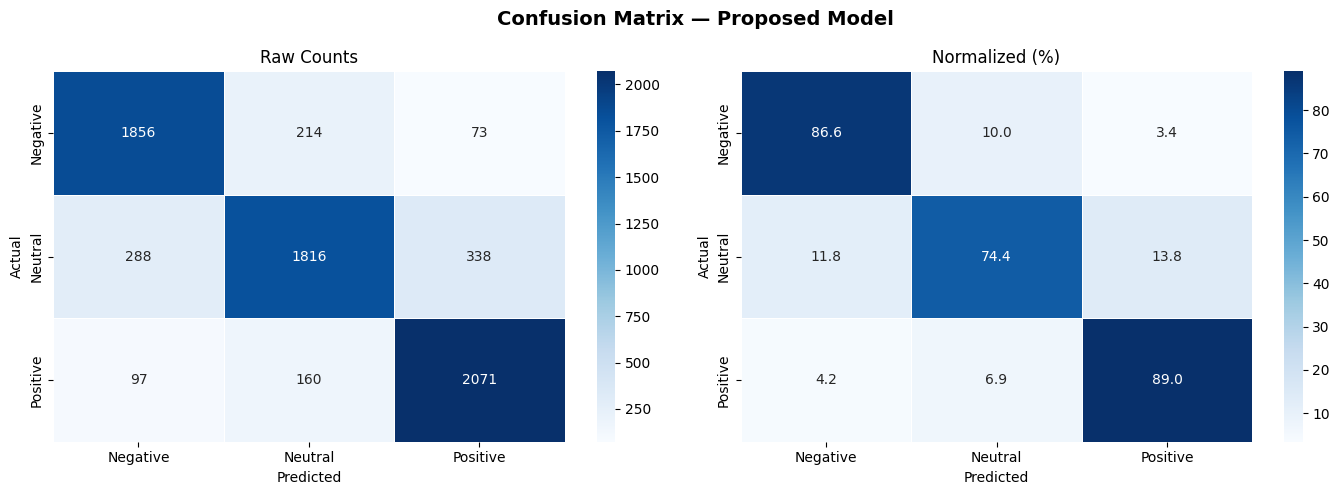

In [4]:
import seaborn as sns
import numpy as np

cm = np.array([[1856, 214,  73],
               [288,  1816, 338],
               [97,   160,  2071]])

cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Confusion Matrix — Proposed Model", fontsize=14, fontweight="bold")

labels = ["Negative", "Neutral", "Positive"]

# Raw counts
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels,
            ax=ax1, linewidths=0.5)
ax1.set_title("Raw Counts"); ax1.set_xlabel("Predicted"); ax1.set_ylabel("Actual")

# Normalized %
sns.heatmap(cm_norm, annot=True, fmt=".1f", cmap="Blues",
            xticklabels=labels, yticklabels=labels,
            ax=ax2, linewidths=0.5)
ax2.set_title("Normalized (%)"); ax2.set_xlabel("Predicted"); ax2.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix_model.png", dpi=150)
plt.show()

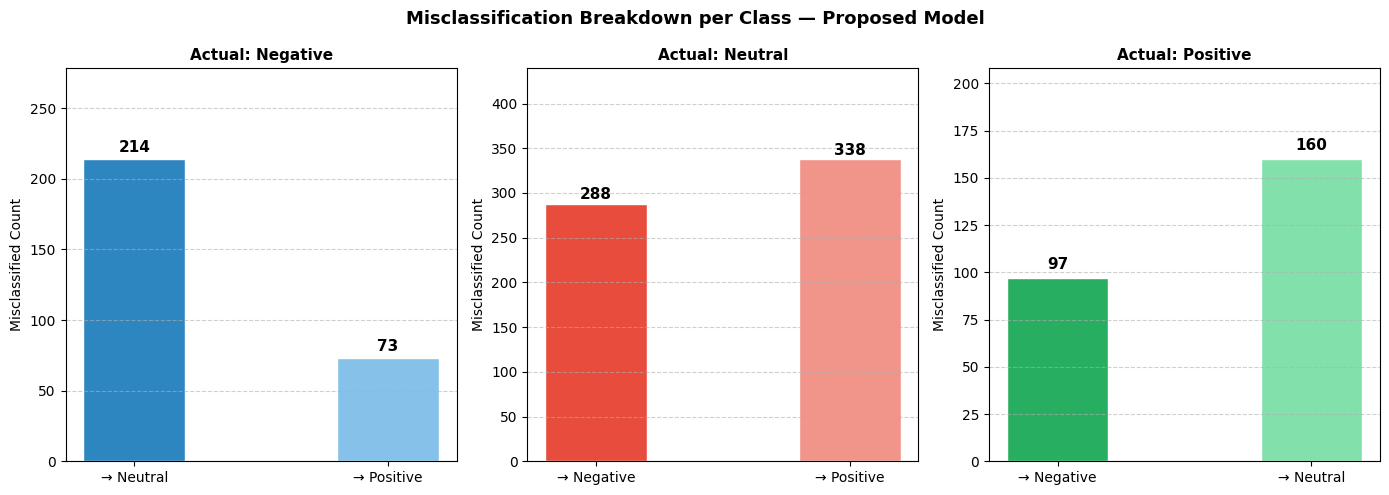

In [5]:
# Shows where wrong predictions go for each class
categories  = ["Negative", "Neutral", "Positive"]
misclassified = {
    "Negative": {"→ Neutral": 214, "→ Positive": 73},
    "Neutral":  {"→ Negative": 288, "→ Positive": 338},
    "Positive": {"→ Negative": 97,  "→ Neutral": 160},
}

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Misclassification Breakdown per Class — Proposed Model",
             fontsize=13, fontweight="bold")

bar_colors = [["#2E86C1","#85C1E9"], ["#E74C3C","#F1948A"], ["#27AE60","#82E0AA"]]

for ax, (cls, errors), colors in zip(axes, misclassified.items(), bar_colors):
    labels = list(errors.keys())
    values = list(errors.values())
    bars = ax.bar(labels, values, color=colors, edgecolor="white", width=0.4)
    ax.set_title(f"Actual: {cls}", fontsize=11, fontweight="bold")
    ax.set_ylabel("Misclassified Count")
    ax.set_ylim(0, max(values) * 1.3)
    ax.grid(axis="y", linestyle="--", alpha=0.6)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(int(bar.get_height())), ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("/kaggle/working/misclassification_breakdown.png", dpi=150)
plt.show()

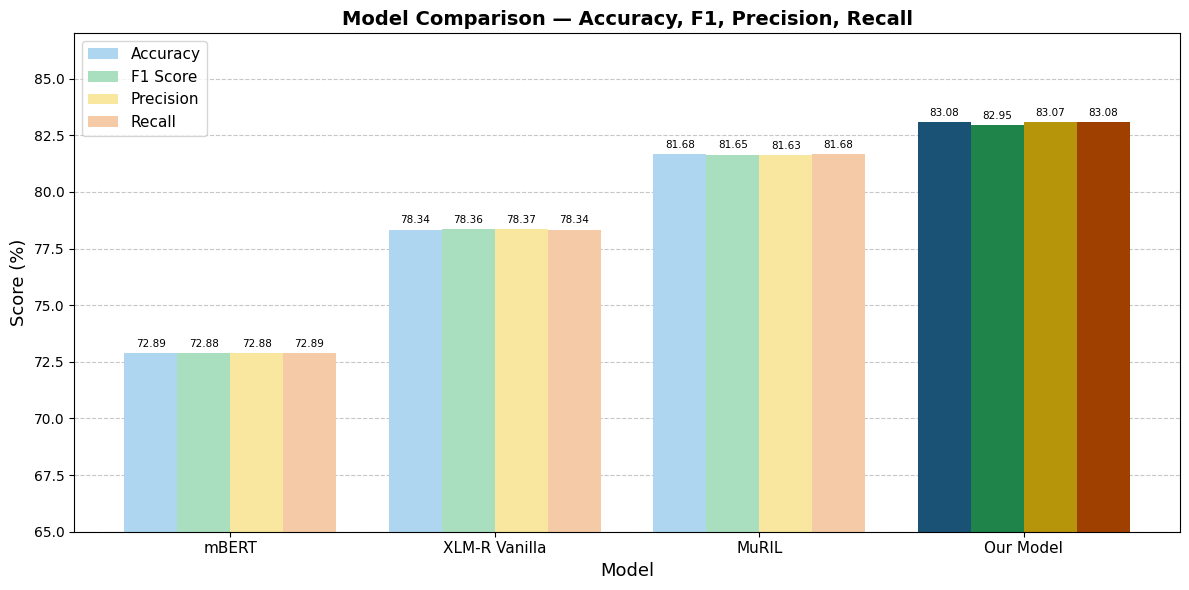

✅ Grouped bar chart saved


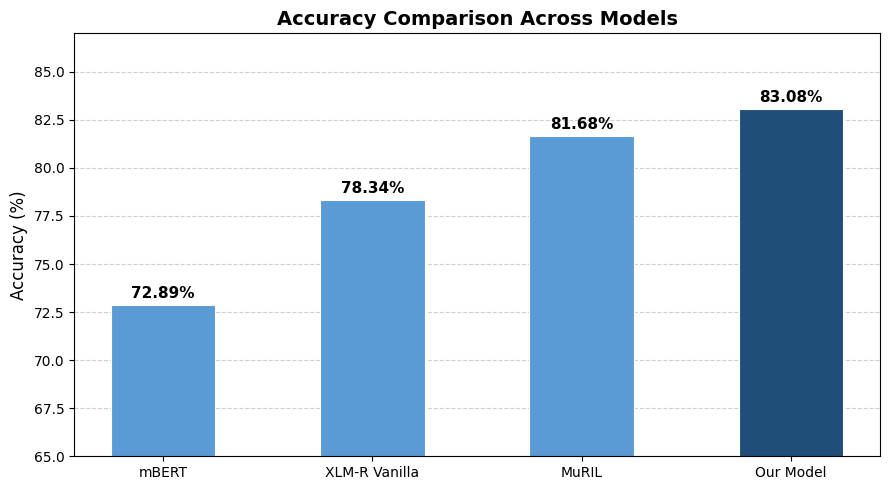

✅ Accuracy bar chart saved


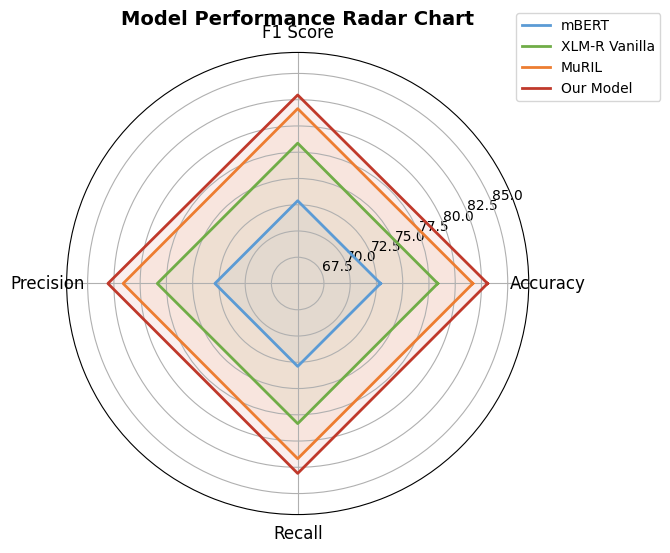

✅ Radar chart saved


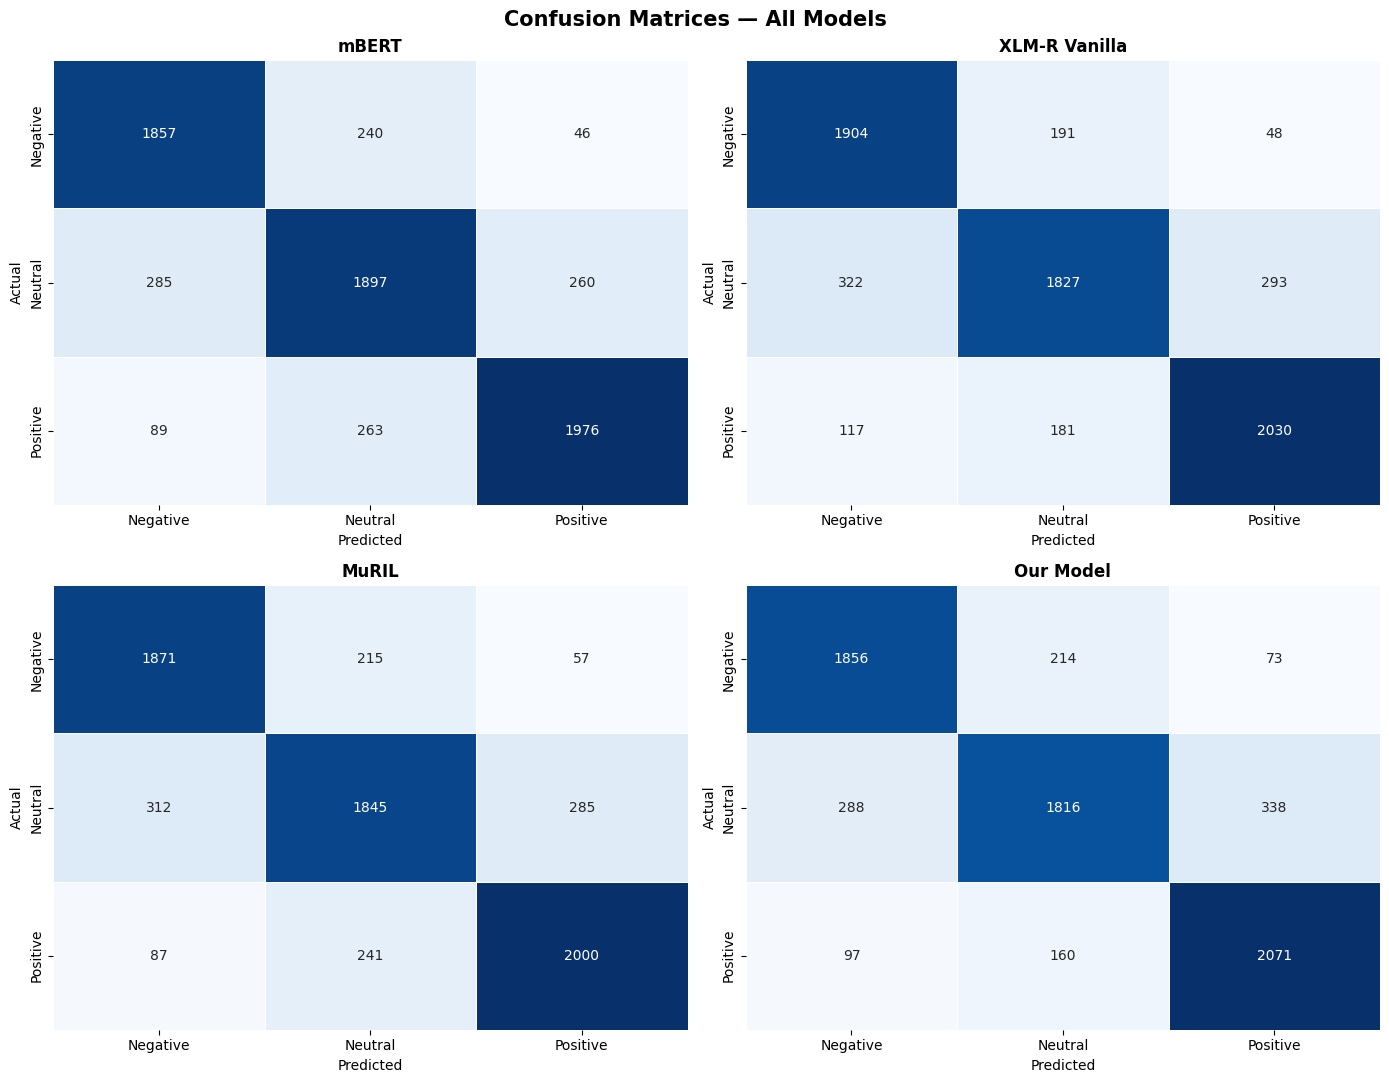

✅ Confusion matrices saved


In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# =========================
# Results Data
# =========================
models = ["mBERT", "XLM-R Vanilla", "MuRIL", "Our Model"]

accuracy  = [72.89, 78.34, 81.68, 83.08]
f1        = [72.88, 78.36, 81.65, 82.95]
precision = [72.88, 78.37, 81.63, 83.07]
recall    = [72.89, 78.34, 81.68, 83.08]

colors = ["#5B9BD5", "#5B9BD5", "#5B9BD5", "#1F4E79"]

# =========================
# 1. Grouped Bar Chart
# =========================
x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - 1.5*width, accuracy,  width, label="Accuracy",  color=["#AED6F1","#AED6F1","#AED6F1","#1A5276"])
bars2 = ax.bar(x - 0.5*width, f1,        width, label="F1 Score",  color=["#A9DFBF","#A9DFBF","#A9DFBF","#1E8449"])
bars3 = ax.bar(x + 0.5*width, precision, width, label="Precision", color=["#F9E79F","#F9E79F","#F9E79F","#B7950B"])
bars4 = ax.bar(x + 1.5*width, recall,    width, label="Recall",    color=["#F5CBA7","#F5CBA7","#F5CBA7","#A04000"])

ax.set_xlabel("Model", fontsize=13)
ax.set_ylabel("Score (%)", fontsize=13)
ax.set_title("Model Comparison — Accuracy, F1, Precision, Recall", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(65, 87)          # ← FIXED: starts at 65 so all bars visible
ax.legend(fontsize=11)
ax.yaxis.grid(True, linestyle="--", alpha=0.7)
ax.set_axisbelow(True)

for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.annotate(f"{h:.2f}",
                xy=(bar.get_x() + bar.get_width() / 2, h),
                xytext=(0, 3), textcoords="offset points",
                ha="center", va="bottom", fontsize=7.5)

plt.tight_layout()
plt.savefig("/kaggle/working/grouped_bar_chart.png", dpi=150)
plt.show()
print("✅ Grouped bar chart saved")

# =========================
# 2. Accuracy-Only Bar Chart
# =========================
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(models, accuracy, color=colors, edgecolor="white", linewidth=0.8, width=0.5)

ax.set_title("Accuracy Comparison Across Models", fontsize=14, fontweight="bold")
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_ylim(65, 87)          # ← FIXED
ax.yaxis.grid(True, linestyle="--", alpha=0.6)
ax.set_axisbelow(True)

for bar in bars:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.2,
                f"{h:.2f}%", ha="center", va="bottom", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("/kaggle/working/accuracy_bar_chart.png", dpi=150)
plt.show()
print("✅ Accuracy bar chart saved")

# =========================
# 3. Radar Chart
# =========================
metrics      = ["Accuracy", "F1 Score", "Precision", "Recall"]
model_scores = {
    "mBERT":         [72.89, 72.88, 72.88, 72.89],
    "XLM-R Vanilla": [78.34, 78.36, 78.37, 78.34],
    "MuRIL":         [81.68, 81.65, 81.62, 81.68],
    "Our Model":     [83.08, 82.95, 83.07, 83.08],
}

N      = len(metrics)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

radar_colors = ["#5B9BD5", "#70AD47", "#ED7D31", "#C0392B"]

for (model_name, scores), color in zip(model_scores.items(), radar_colors):
    vals = scores + scores[:1]
    ax.plot(angles, vals, color=color, linewidth=2, label=model_name)
    ax.fill(angles, vals, color=color, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(65, 87)          # ← FIXED: wide enough to show all models
ax.set_title("Model Performance Radar Chart", fontsize=14, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=10)

plt.tight_layout()
plt.savefig("/kaggle/working/radar_chart.png", dpi=150)
plt.show()
print("✅ Radar chart saved")

# =========================
# 4. Confusion Matrix Heatmaps (2x2 grid, all 4 models)
# =========================
import seaborn as sns

cms = {
    "mBERT": np.array([[1857, 240,  46],
                       [285,  1897, 260],
                       [89,   263,  1976]]),

    "XLM-R Vanilla": np.array([[1904, 191,  48],
                                [322,  1827, 293],
                                [117,  181,  2030]]),

    "MuRIL":         np.array([[1871, 215,  57],
                                [312,  1845, 285],
                                [87,   241,  2000]]),

    "Our Model":     np.array([[1856, 214,  73],
                                [288,  1816, 338],
                                [97,   160,  2071]]),
}

class_names = ["Negative", "Neutral", "Positive"]

fig, axes = plt.subplots(2, 2, figsize=(14, 11))   # ← 2x2 grid for all 4
fig.suptitle("Confusion Matrices — All Models", fontsize=15, fontweight="bold")

for ax, (model_name, cm) in zip(axes.flatten(), cms.items()):
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax, cbar=False, linewidths=0.5
    )
    ax.set_title(model_name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicted", fontsize=10)
    ax.set_ylabel("Actual", fontsize=10)

plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrices.png", dpi=150)
plt.show()
print("✅ Confusion matrices saved")